# Stationarity in Time Series

---

## 1. What is Stationarity?

A time series $\{X_t\}$ is said to be **weakly stationary** (or *covariance stationary*) if the following three conditions hold for all $t$:

### Condition 1 — Constant Mean
$$\mathbb{E}[X_t] = \mu \quad \forall t$$

The expected value of the series does not change over time.

### Condition 2 — Constant Variance
$$\text{Var}(X_t) = \sigma^2 < \infty \quad \forall t$$

The variance is finite and does not change over time.

### Condition 3 — Autocovariance Depends Only on Lag
$$\text{Cov}(X_t, X_{t-k}) = \gamma(k) \quad \forall t, k$$

The autocovariance between any two observations depends only on the **distance** $k$ between them (the lag), not on where in time $t$ we are.

> **Intuition:** A stationary series behaves statistically the same regardless of *when* you observe it — the rules governing it do not change over time.

---

## 2. Strict vs Weak Stationarity

| Type | Definition | Practical Use |
|------|-----------|---------------|
| **Strict Stationarity** | The entire joint distribution of $(X_{t_1}, ..., X_{t_n})$ is invariant to time shifts | Theoretically precise but hard to test |
| **Weak Stationarity** | Only the first two moments (mean, variance) and autocovariance are stable | Standard assumption in finance and ML |

In financial time series, **weak stationarity** is almost always what we mean and test for.

---

## 3. Non-Stationarity — When the Rules Keep Changing

A series is **non-stationary** if any of the three conditions above are violated. Raw asset prices $P_t$ are a classic example:

- **Trending mean:** $\mathbb{E}[P_t] \neq \mathbb{E}[P_s]$ for $t \neq s$ — prices drift upward over decades
- **Changing variance:** $\text{Var}(P_t)$ clusters — calm periods followed by turbulent ones (heteroskedasticity)
- **Regime shifts:** statistical relationships change entirely across bull/bear markets

The most common model for a non-stationary price series is a **Random Walk**:

$$P_t = P_{t-1} + \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0, \sigma^2)$$

Here the variance grows unboundedly with time:

$$\text{Var}(P_t) = t \cdot \sigma^2 \rightarrow \infty \text{ as } t \rightarrow \infty$$

This makes raw prices **unreliable** for building predictive models — any pattern found in one period may not hold in another.

---

## 4. The Remedy — Differencing to Achieve Stationarity

The standard solution is to replace prices with their **first differences** (returns):

$$\rho_t = P_t - P_{t-1}$$

Or equivalently, **log returns**:

$$\rho_t = \ln\left(\frac{P_t}{P_{t-1}}\right) = \ln(P_t) - \ln(P_{t-1})$$

Differencing removes the deterministic trend and stabilises the variance, making the series much closer to stationary:

$$\mathbb{E}[\rho_t] \approx \mu \quad \text{(approximately constant)}$$
$$\text{Var}(\rho_t) \approx \sigma^2 \quad \text{(approximately stable)}$$

> **Key insight:** We do not model *where prices are* — we model *how prices change*. This is a more defensible and statistically sound assumption.

---

## 5. Testing for Stationarity

Stationarity is not just visually inspected — it is formally verified using statistical hypothesis tests.

### Augmented Dickey-Fuller (ADF) Test

The ADF test checks whether a **unit root** is present. The test regression is:

$$\Delta X_t = \alpha + \beta t + \gamma X_{t-1} + \sum_{i=1}^{p} \delta_i \Delta X_{t-i} + \varepsilon_t$$

Where:
- $\Delta X_t = X_t - X_{t-1}$ is the first difference
- $\gamma$ is the coefficient of interest

**Hypotheses:**
$$H_0: \gamma = 0 \quad \text{(unit root exists → non-stationary)}$$
$$H_1: \gamma < 0 \quad \text{(no unit root → stationary)}$$

If the **p-value < 0.05**, we reject $H_0$ and conclude the series is stationary.

### KPSS Test

The KPSS test has the **opposite null hypothesis** — it assumes stationarity by default:

$$H_0: \text{Series is stationary}$$
$$H_1: \text{Series has a unit root (non-stationary)}$$

> **Best practice:** Run **both** ADF and KPSS together. If ADF rejects $H_0$ *and* KPSS fails to reject $H_0$, you have strong evidence of stationarity.

---

## 6. Summary Table

| Series | Stationary? | Why |
|--------|------------|-----|
| Raw price $P_t$ | ❌ No | Trending mean, exploding variance |
| Log returns $\rho_t = \ln(P_t/P_{t-1})$ | ✅ Approximately | Mean ~0, stable variance |
| Squared returns $\rho_t^2$ | ⚠️ Often No | Volatility clustering (ARCH effects) |


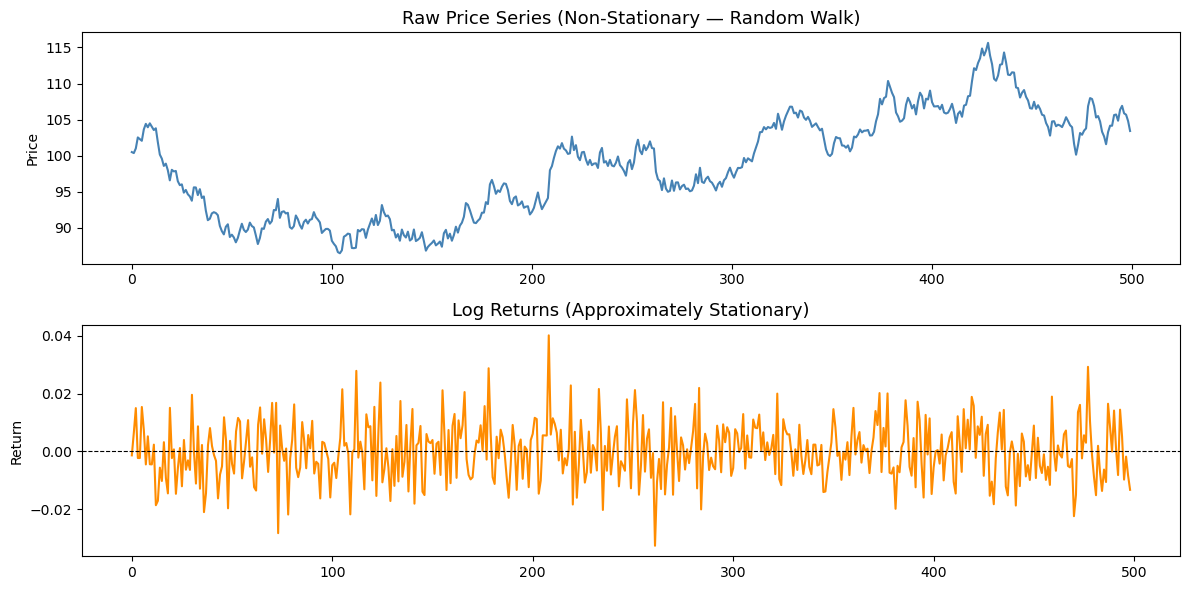

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss

# Example: Simulating a Non-Stationary vs Stationary Series
np.random.seed(42)
n = 500

# Non-stationary: Random Walk (simulating raw prices)
epsilon = np.random.normal(0, 1, n)
price = np.cumsum(epsilon) + 100  # starts at 100

# Stationary: First differences (log returns)
returns = np.diff(np.log(price))

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(price, color='steelblue')
axes[0].set_title('Raw Price Series (Non-Stationary — Random Walk)', fontsize=13)
axes[0].set_ylabel('Price')

axes[1].plot(returns, color='darkorange')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Log Returns (Approximately Stationary)', fontsize=13)
axes[1].set_ylabel('Return')

plt.tight_layout()
plt.show()

In [2]:
# -------------------------------------------------------
# ADF Test
# -------------------------------------------------------

def run_adf(series, name):
    result = adfuller(series, autolag='AIC')
    print(f"--- ADF Test: {name} ---")
    print(f"  Test Statistic : {result[0]:.4f}")
    print(f"  p-value        : {result[1]:.4f}")
    print(f"  Conclusion     : {'Stationary ✅' if result[1] < 0.05 else 'Non-Stationary ❌'}")
    print()

run_adf(price, 'Raw Price')
run_adf(returns, 'Log Returns')

--- ADF Test: Raw Price ---
  Test Statistic : -1.4986
  p-value        : 0.5342
  Conclusion     : Non-Stationary ❌

--- ADF Test: Log Returns ---
  Test Statistic : -22.5469
  p-value        : 0.0000
  Conclusion     : Stationary ✅



In [3]:
# -------------------------------------------------------
# KPSS Test
# -------------------------------------------------------

def run_kpss(series, name):
    result = kpss(series, regression='c', nlags='auto')
    print(f"--- KPSS Test: {name} ---")
    print(f"  Test Statistic : {result[0]:.4f}")
    print(f"  p-value        : {result[1]:.4f}")
    print(f"  Conclusion     : {'Stationary ✅' if result[1] > 0.05 else 'Non-Stationary ❌'}")
    print()

run_kpss(price, 'Raw Price')
run_kpss(returns, 'Log Returns')

--- KPSS Test: Raw Price ---
  Test Statistic : 2.8794
  p-value        : 0.0100
  Conclusion     : Non-Stationary ❌

--- KPSS Test: Log Returns ---
  Test Statistic : 0.1109
  p-value        : 0.1000
  Conclusion     : Stationary ✅



/var/folders/8w/ssf6h_nx3jj8xkvsdz8b1cmw0000gn/T/ipykernel_30245/3354802966.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(series, regression='c', nlags='auto')
/var/folders/8w/ssf6h_nx3jj8xkvsdz8b1cmw0000gn/T/ipykernel_30245/3354802966.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series, regression='c', nlags='auto')
